In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Load cleaned data
oil = pd.read_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/oil_prices_cleaned.csv", index_col=0, parse_dates=True)

# Prophet requires specific column names - ds (date) and y (value)
prophet_df = oil[["Price"]].reset_index()
prophet_df.columns = ["ds", "y"]

print(prophet_df.shape)
print(prophet_df.head())
print(prophet_df.tail())

(4082, 2)
          ds          y
0 2015-01-02  56.419998
1 2015-01-03  56.419998
2 2015-01-04  56.419998
3 2015-01-05  53.110001
4 2015-01-06  51.099998
             ds          y
4077 2026-03-02  77.739998
4078 2026-03-03  81.400002
4079 2026-03-04  81.400002
4080 2026-03-05  85.410004
4081 2026-03-06  92.690002


In [17]:
# Split data into training and testing
# Train on everything up to 2024, test on 2025 onwards
train = prophet_df[prophet_df["ds"] < "2025-01-01"]
test = prophet_df[prophet_df["ds"] >= "2025-01-01"]

print(f"Training data: {len(train)} rows")
print(f"Testing data: {len(test)} rows")

# Build and train the model
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    changepoint_prior_scale=0.5  # controls flexibility of trend
)

model.fit(train)
print("\nModel trained successfully!")

Training data: 3652 rows
Testing data: 430 rows


17:22:35 - cmdstanpy - INFO - Chain [1] start processing
17:22:39 - cmdstanpy - INFO - Chain [1] done processing



Model trained successfully!


In [24]:
# Make future dataframe - predict through end of 2026
future = model.make_future_dataframe(periods=1000)

# Generate predictions
forecast = model.predict(future)

# Show key columns
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10))

             ds       yhat  yhat_lower  yhat_upper
4642 2027-09-18  70.607556 -171.510537  328.425357
4643 2027-09-19  70.611203 -175.994570  333.238394
4644 2027-09-20  70.510585 -176.295353  329.043166
4645 2027-09-21  70.488692 -172.205727  329.169171
4646 2027-09-22  70.516835 -175.893609  332.789936
4647 2027-09-23  70.637569 -175.310432  331.476119
4648 2027-09-24  70.834784 -174.061278  333.595934
4649 2027-09-25  70.900265 -177.517287  335.874871
4650 2027-09-26  70.974927 -177.835593  335.907282
4651 2027-09-27  70.944146 -176.974252  335.309378


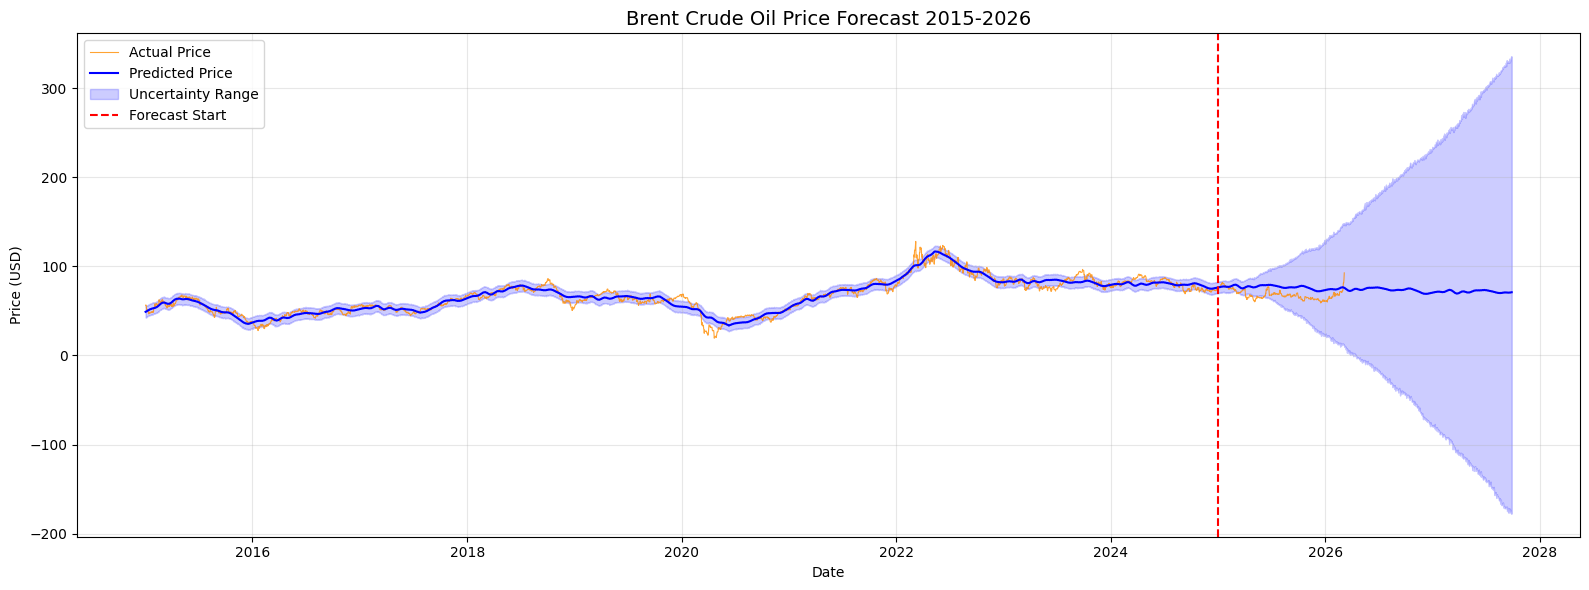

In [25]:
# Plot the forecast
fig, ax = plt.subplots(figsize=(16, 6))

# Plot actual prices
ax.plot(prophet_df["ds"], prophet_df["y"], 
        color="darkorange", linewidth=0.8, label="Actual Price", alpha=0.8)

# Plot predicted prices
ax.plot(forecast["ds"], forecast["yhat"], 
        color="blue", linewidth=1.5, label="Predicted Price")

# Plot uncertainty bands
ax.fill_between(forecast["ds"], 
                forecast["yhat_lower"], 
                forecast["yhat_upper"], 
                alpha=0.2, color="blue", label="Uncertainty Range")

# Add vertical line showing where prediction starts
ax.axvline(x=pd.Timestamp("2025-01-01"), 
           color="red", linestyle="--", label="Forecast Start")

ax.set_title("Brent Crude Oil Price Forecast 2015-2026", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Price (USD)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
# Merge forecast with actual test data
forecast_test = forecast[forecast["ds"] >= "2025-01-01"][["ds", "yhat"]]
test_merged = test.merge(forecast_test, on="ds", how="inner")

# Calculate accuracy metrics
mae = mean_absolute_error(test_merged["y"], test_merged["yhat"])
rmse = np.sqrt(mean_squared_error(test_merged["y"], test_merged["yhat"]))
mape = np.mean(np.abs((test_merged["y"] - test_merged["yhat"]) / test_merged["y"])) * 100

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")
print(f"\nThis means on average our model is off by ${mae:.2f} per barrel")

Mean Absolute Error (MAE): $8.61
Root Mean Squared Error (RMSE): $9.53
Mean Absolute Percentage Error (MAPE): 13.07%

This means on average our model is off by $8.61 per barrel


In [27]:
import os

# Create folders if they don't exist
os.makedirs("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/models", exist_ok=True)

print("Folders created!")

Folders created!


In [28]:
import pickle

# Save the model
with open("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/models/prophet_model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save forecast
forecast.to_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/forecast.csv", index=False)

print("Model and forecast saved!")


Model and forecast saved!


In [29]:
print(f"Last date in forecast: {forecast['ds'].max()}")
print(f"Last date in oil data: {oil.index.max()}")

Last date in forecast: 2027-09-27 00:00:00
Last date in oil data: 2026-03-06 00:00:00


In [30]:
# Check how many days exist after last oil date
last_oil_date = pd.Timestamp("2026-03-06")
future_only = forecast[forecast["ds"] > last_oil_date]
print(f"Future forecast rows: {len(future_only)}")
print(future_only[["ds", "yhat"]].head(10))

Future forecast rows: 570
             ds       yhat
4082 2026-03-07  75.817700
4083 2026-03-08  75.600912
4084 2026-03-09  75.251935
4085 2026-03-10  74.956782
4086 2026-03-11  74.690379
4087 2026-03-12  74.499416
4088 2026-03-13  74.372361
4089 2026-03-14  74.105923
4090 2026-03-15  73.846187
4091 2026-03-16  73.483830


In [31]:
forecast.to_csv("C:/Users/DEEBYTE COMPUTERS/Documents/oil-forecasting-pipeline/data/forecast.csv", index=False)
print("Forecast saved!")

Forecast saved!
